In [1]:
%load_ext autoreload
%autoreload 2
%load_ext line_profiler
import moabb
from moabb.datasets import *
from moabb.paradigms import P300
from hoda.hoda import HODA
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from mne.viz import plot_topomap
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import roc_auc_score
from sklearn.manifold import TSNE
from mne.decoding import Scaler
from mne import combine_evoked

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [2]:
fmax=16
sfreq=64
paradigm = P300(resample=sfreq, tmin=0, tmax=0.8, fmin=0.5, fmax=fmax)
#dataset = EPFLP300()
#subject, session, run = 1, "session_1", "run_1"
dataset = BNCI2014009()
subject, session, run = 1, "session_0", "run_0"


In [3]:
dataset.download(subject_list=[subject])
data = dataset.get_data(subjects=[subject])
raw = data[subject][session][run]
raw.info
epochs, labels, _ = paradigm.process_raw(raw, dataset, return_epochs=True)
epochs

Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Creating RawArray with float64 data, n_channels=18, n_times=50184
    Range : 0 ... 50183 =      0.000 ...   196.027 secs
Ready.
Not setting metadata
576 matching events found
No baseline correction applied


Number of events,576
Events,NonTarget: 480Target: 96
Time range,0.000 – 0.797 sec
Baseline,off


No projector specified for this dataset. Please consider the method self.add_proj.


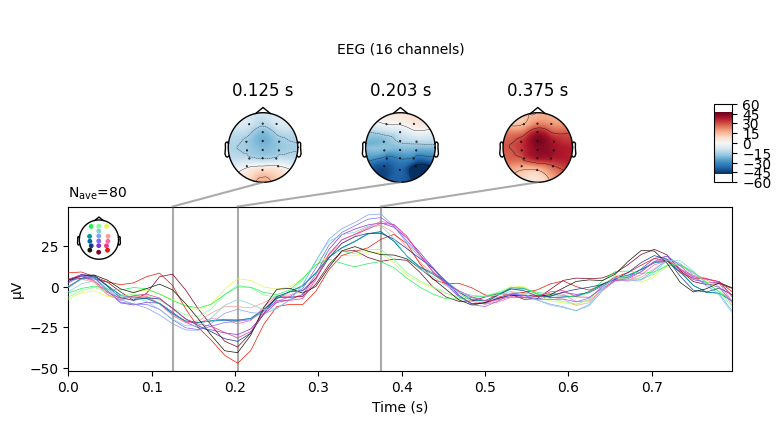

In [4]:
from mne import combine_evoked
target = epochs['Target'].average()
non_target = epochs['NonTarget'].average()
contrast = combine_evoked([target, non_target], weights=[1,-1])
#contrast.apply_baseline((-0.2,0))
_= contrast.plot_joint()

In [5]:
contrast = combine_evoked([epochs['Target'].average(), epochs['NonTarget'].average()], weights=[1,-1])

In [6]:
#split=100
split = len(epochs)//2
epochs_train = epochs[:split]
epochs_test = epochs[split:]
labels_train = labels[:split]
labels_test = labels[split:]

In [7]:
import tensorly.decomposition
import matplotlib.pyplot as plt
import tensorly as tl

tl.set_backend('numpy')

X_train = epochs_train.get_data().astype(np.float32)
y_train = labels_train
X_test = epochs_test.get_data().astype(np.float32)
y_test = labels_test

In [24]:
from hoda.hoda import BTTDA
from sklearn.pipeline import Pipeline
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from mne.decoding import Scaler

n_blocks=3
bttda_lda = Pipeline([
    ('scaler', Scaler(with_mean=True, scalings='mean')),
    ('bttda', BTTDA(
    n_blocks=n_blocks,
    hoda_params=dict(
            rank=None,
            max_iter=256,
            tol=1e-3,
            init ='mlsvd',
            verbose=True,
            shrinkage=('lw','lw'),
            toeplitz=(1,),
            solver='diff',
            keep_train_info=True,
            taper=False,
    ),
    keep_train_info=True,
    verbose=True)
    ),
    ('lda', LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr')),
])
                       

bttda_lda.fit(X_train,y_train)

Fitting block 1/3...
Initializing factors...
Fitting discriminative tucker model of rank [2, 2] ...


  0%|          | 0/256 [00:00<?, ?it/s]


Fitting block 2/3...
Initializing factors...
Fitting discriminative tucker model of rank [3, 3] ...


  0%|          | 0/256 [00:00<?, ?it/s]


Fitting block 3/3...
Initializing factors...
Fitting discriminative tucker model of rank [4, 3] ...


  0%|          | 0/256 [00:00<?, ?it/s]

Pipeline(steps=[('scaler',
                 Scaler({'info': None, 'scalings': 'mean', 'with_mean': True, 'with_std': True})),
                ('bttda',
                 BTTDA(hoda_params={'init': 'mlsvd', 'keep_train_info': True,
                                    'max_iter': 256, 'rank': None,
                                    'shrinkage': ('lw', 'lw'), 'solver': 'diff',
                                    'taper': False, 'toeplitz': (1,),
                                    'tol': 0.001, 'verbose': True},
                       keep_train_info=True, n_blocks=3, verbose=True)),
                ('lda',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])

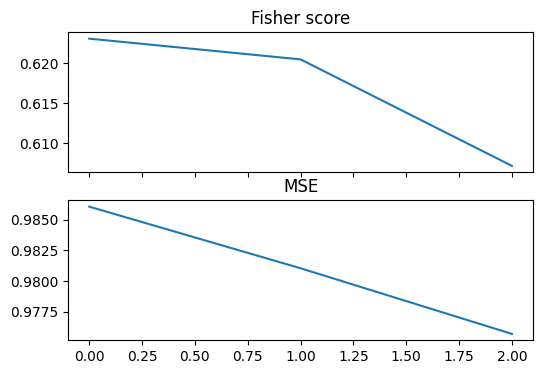

In [17]:
fig, axs = plt.subplots(2,1, sharex=True, figsize=(6,4))

axs[0].set_title('Fisher score')
axs[0].plot(bttda_lda['bttda'].train_info_["f_score"])

axs[1].set_title('MSE')
axs[1].plot(bttda_lda['bttda'].train_info_["mse"])



In [18]:
"""
for b in range(n_blocks):
    fig, axs = plt.subplots(1,max(bttda_lda['bttda'].blocks_[b].rank_[0],2), figsize=(16,6), layout='tight')
    for i in range(bttda_lda['bttda'].blocks_[b].rank_[0]):
        w = cupy.asnumpy(bttda_lda['bttda'].blocks_[b].scalings_[0][:,i])
        plot_topomap(w, epochs.info, axes=axs[i], show=False)

    fig, axs = plt.subplots(1,max(bttda_lda['bttda'].blocks_[b].rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
    for i in range(bttda_lda['bttda'].blocks_[b].rank_[1]):
        w = cupy.asnumpy(bttda_lda['bttda'].blocks_[b].scalings_[1][:,i])
        axs[i].plot(epochs.times, w)
        axs[i].set_xlabel('Time (s)')
        axs[i].sharey(axs[0])
    axs[0].set_ylabel('Weight');
"""

"\nfor b in range(n_blocks):\n    fig, axs = plt.subplots(1,max(bttda_lda['bttda'].blocks_[b].rank_[0],2), figsize=(16,6), layout='tight')\n    for i in range(bttda_lda['bttda'].blocks_[b].rank_[0]):\n        w = cupy.asnumpy(bttda_lda['bttda'].blocks_[b].scalings_[0][:,i])\n        plot_topomap(w, epochs.info, axes=axs[i], show=False)\n\n    fig, axs = plt.subplots(1,max(bttda_lda['bttda'].blocks_[b].rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)\n    for i in range(bttda_lda['bttda'].blocks_[b].rank_[1]):\n        w = cupy.asnumpy(bttda_lda['bttda'].blocks_[b].scalings_[1][:,i])\n        axs[i].plot(epochs.times, w)\n        axs[i].set_xlabel('Time (s)')\n        axs[i].sharey(axs[0])\n    axs[0].set_ylabel('Weight');\n"

In [19]:
"""
for b in range(n_blocks):
    fig, axs = plt.subplots(1,max(bttda_lda['bttda'].blocks_[b].rank_[0],2), figsize=(16,6), layout='tight')
    for i in range(bttda_lda['bttda'].blocks_[b].rank_[0]):
        w = cupy.asnumpy(bttda_lda['bttda'].blocks_[b].scalings_[0][:,i]@bttda_lda['bttda'].blocks_[b].scatter_w_[0])
        plot_topomap(w, epochs.info, axes=axs[i], show=False)

    fig, axs = plt.subplots(1,max(bttda_lda['bttda'].blocks_[b].rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)
    for i in range(bttda_lda['bttda'].blocks_[b].rank_[1]):
        w = cupy.asnumpy(bttda_lda['bttda'].blocks_[b].scalings_[1][:,i]@bttda_lda['bttda'].blocks_[b].scatter_w_[1])
        axs[i].plot(epochs.times, w)
        axs[i].set_xlabel('Time (s)')
        axs[i].sharey(axs[0])
    axs[0].set_ylabel('Weight');
"""

"\nfor b in range(n_blocks):\n    fig, axs = plt.subplots(1,max(bttda_lda['bttda'].blocks_[b].rank_[0],2), figsize=(16,6), layout='tight')\n    for i in range(bttda_lda['bttda'].blocks_[b].rank_[0]):\n        w = cupy.asnumpy(bttda_lda['bttda'].blocks_[b].scalings_[0][:,i]@bttda_lda['bttda'].blocks_[b].scatter_w_[0])\n        plot_topomap(w, epochs.info, axes=axs[i], show=False)\n\n    fig, axs = plt.subplots(1,max(bttda_lda['bttda'].blocks_[b].rank_[1],2), figsize=(16,6), layout='tight', sharex=True, sharey=True)\n    for i in range(bttda_lda['bttda'].blocks_[b].rank_[1]):\n        w = cupy.asnumpy(bttda_lda['bttda'].blocks_[b].scalings_[1][:,i]@bttda_lda['bttda'].blocks_[b].scatter_w_[1])\n        axs[i].plot(epochs.times, w)\n        axs[i].set_xlabel('Time (s)')\n        axs[i].sharey(axs[0])\n    axs[0].set_ylabel('Weight');\n"

<AxesSubplot: xlabel='score', ylabel='Count'>

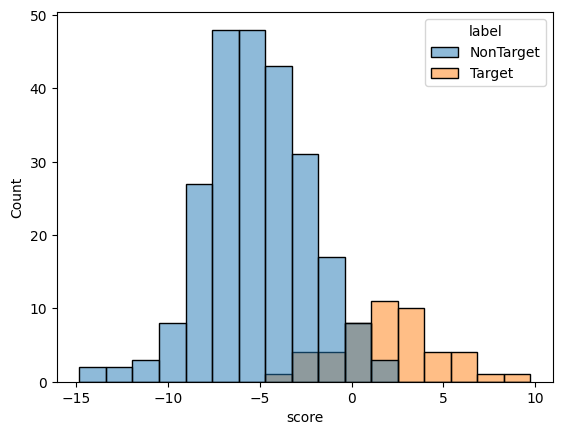

In [20]:
import pandas as pd
import cupy

train_scores = cupy.asnumpy(bttda_lda.decision_function(X_train))
df = pd.DataFrame(dict(score=cupy.asnumpy(train_scores),label=labels_train))
sns.histplot(data=df, x='score', hue='label')

In [21]:
roc_auc_score(y_train,train_scores)

0.9697916666666666

<AxesSubplot: xlabel='score', ylabel='Count'>

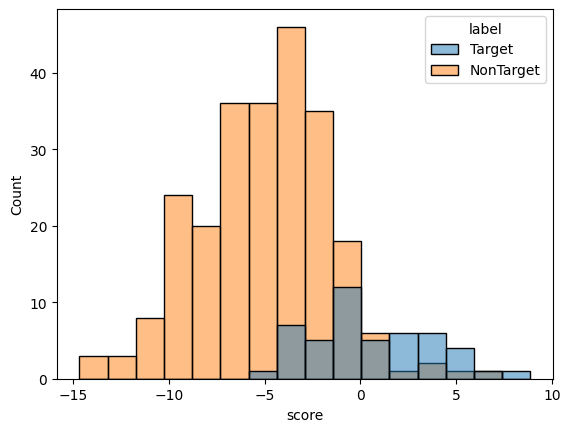

In [22]:
test_scores = cupy.asnumpy(bttda_lda.decision_function(X_test))
df = pd.DataFrame(dict(score=cupy.asnumpy(test_scores),label=labels_test))
sns.histplot(data=df, x='score', hue='label')

In [23]:
roc_auc_score(y_test,test_scores)

0.8901909722222222